<a href="https://colab.research.google.com/github/R0dr1g0-23/Algoritmo-e-Estrutura-de-Dados/blob/main/Heaps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heaps e Filas de Prioridade — Tutorial

## Objetivos

Ao final deste tutorial você será capaz de:

- Representar um heap binário em um array e navegar por índices (pai/filhos)
- Implementar `sift_down`, `build_heap`, `insert` e `extract_min` do zero
- Usar o módulo `heapq` como fila de prioridade
- Implementar e analisar o **Heap Sort** in-place

## 1. Heap como array

Um heap binário é uma árvore quase completa armazenada em um array, sem ponteiros.
Para um índice `i` (base 0): o pai é `(i-1)//2`, o filho esquerdo é `2*i+1` e o
direito é `2*i+2`. Em um **min-heap**, todo nó é menor ou igual a seus filhos.

In [12]:
# Exemplo: navegação por índices e verificação da propriedade de min-heap
def pai(i):  # índice do pai de i
    return (i - 1) // 2

def esq(i):  # índice do filho esquerdo
    return 2 * i + 1

def dir(i):  # índice do filho direito
    return 2 * i + 2

def eh_min_heap(a):
    # todo nó deve ser <= seus filhos existentes
    n = len(a)
    for i in range(n):
        for c in (esq(i), dir(i)):
            if c < n and a[i] > a[c]:
                return False
    return True

print(eh_min_heap([1, 3, 6, 5, 9, 8]))  # True
print(eh_min_heap([1, 3, 6, 5, 2, 8]))  # False (2 < pai 3)

True
False


In [13]:
# Exercício 1: propriedade de max-heap
# TODO: implemente eh_max_heap(a) que retorna True se todo nó >= seus filhos.

def eh_max_heap(vector):
    #todo nó deve ser maior que seus filhos
    n = len(vector)
    for i in range(n): #percorre todos os valores
        for c in (esq(i), dir(i)):
            if c < n and vector[i] < vector[c]:
                return False
    return True

# Teste automático
assert eh_max_heap([9, 5, 8, 3, 1]) == True, 'Verifique sua implementação'
assert eh_max_heap([9, 5, 8, 3, 7]) == False, 'Verifique sua implementação'

## 2. Operações: sift_down, build_heap, insert, extract_min

`sift_down` empurra um nó para baixo até restaurar a propriedade; `sift_up` o
sobe após uma inserção. A partir deles construímos todas as operações. Note que
`build_heap` aplica `sift_down` de baixo para cima em tempo $O(n)$.

In [14]:
# Exemplo: min-heap completo implementado do zero
def sift_down(a, i, n=None):
    n = len(a) if n is None else n
    while True:
        menor = i
        for c in (esq(i), dir(i)):       # acha o menor entre nó e filhos
            if c < n and a[c] < a[menor]:
                menor = c
        if menor == i:                   # propriedade ok: termina
            break
        a[i], a[menor] = a[menor], a[i]  # troca e continua descendo
        i = menor

def sift_up(a, i):
    while i > 0 and a[i] < a[pai(i)]:     # menor que o pai: sobe
        a[i], a[pai(i)] = a[pai(i)], a[i]
        i = pai(i)

def build_heap(a):
    for i in range(len(a) // 2 - 1, -1, -1):  # do último nó interno à raiz
        sift_down(a, i)
    return a

def insert(a, x):
    a.append(x)            # anexa ao fim
    sift_up(a, len(a) - 1) # restaura subindo

def extract_min(a):
    minimo = a[0]          # raiz = menor
    ultimo = a.pop()       # remove o último
    if a:
        a[0] = ultimo      # traz ao topo e desce
        sift_down(a, 0)
    return minimo

h = build_heap([9, 4, 7, 1, 8, 3, 6])
print('heap:', h, '| eh_min_heap:', eh_min_heap(h))
insert(h, 0)
print('menor apos insert(0):', h[0])
print('extraindo em ordem:', [extract_min(h) for _ in range(len(h))])

heap: [1, 4, 3, 9, 8, 7, 6] | eh_min_heap: True
menor apos insert(0): 0
extraindo em ordem: [0, 1, 3, 4, 6, 7, 8, 9]


In [15]:
# Exercício 2: extract_min em sequência produz ordem crescente
# TODO: implemente heap_ordenado(valores) que insere todos os valores em um
# min-heap (lista vazia + insert) e retorna a lista obtida por extract_min
# sucessivos.

def heap_ordenado(valores):
    newheap = list()
    saida = list()
    for x in valores:
        insert(newheap,x)
    while newheap:
        saida.append(extract_min(newheap))
    return saida


# Teste automático
assert heap_ordenado([5, 2, 8, 1, 9, 3]) == [1, 2, 3, 5, 8, 9], 'Verifique sua implementação'

## 3. Filas de prioridade com `heapq`

A biblioteca padrão do Python oferece um min-heap pronto no módulo `heapq`.
`heappush` insere e `heappop` remove o menor — ambos em $O(\log n)$. Para
prioridade por chave, empurramos tuplas `(prioridade, item)`.

In [16]:
# Exemplo: fila de prioridade de tarefas (menor número = maior prioridade)
import heapq

fila = []
heapq.heappush(fila, (2, 'fazer backup'))
heapq.heappush(fila, (1, 'corrigir bug critico'))
heapq.heappush(fila, (3, 'responder email'))

while fila:
    prioridade, tarefa = heapq.heappop(fila)  # sempre a maior prioridade
    print(f'[{prioridade}] {tarefa}')

[1] corrigir bug critico
[2] fazer backup
[3] responder email


In [17]:
# Exercício 3: k menores elementos
# TODO: implemente k_menores(valores, k) usando heapq, devolvendo os k menores
# em ordem crescente. Dica: heapq.nsmallest existe, mas implemente com
# heappush/heappop para praticar.

def k_menores(valores, k):
    lista = list()
    saida = list()

    for x in valores:
        heapq.heappush(lista, x)

    x = 0
    while x < k:
      saida.append(heapq.heappop(lista))
      x += 1

    return saida

# Teste automático
assert k_menores([7, 1, 5, 2, 9, 3], 3) == [1, 2, 3], 'Verifique sua implementação'

## 4. Heap Sort in-place

Construímos um **max-heap** e trocamos a raiz (máximo) com o último elemento,
encolhendo o heap e aplicando `sift_down`. O resultado é um array ordenado em
ordem crescente, sem memória extra ($O(1)$), com tempo $O(n\log n)$.

In [18]:
# Exemplo: heap sort in-place usando um max-heap
def sift_down_max(a, i, n):
    while True:
        maior = i
        for c in (2 * i + 1, 2 * i + 2):
            if c < n and a[c] > a[maior]:
                maior = c
        if maior == i:
            break
        a[i], a[maior] = a[maior], a[i]
        i = maior

def heap_sort(a):
    n = len(a)
    for i in range(n // 2 - 1, -1, -1):   # build max-heap
        sift_down_max(a, i, n)
    for fim in range(n - 1, 0, -1):       # extrai o maximo repetidamente
        a[0], a[fim] = a[fim], a[0]        # maximo vai para o fim
        sift_down_max(a, 0, fim)           # heap encolhe para 'fim'
    return a

print(heap_sort([9, 4, 7, 1, 8, 3, 6, 2]))  # [1, 2, 3, 4, 6, 7, 8, 9]

[1, 2, 3, 4, 6, 7, 8, 9]


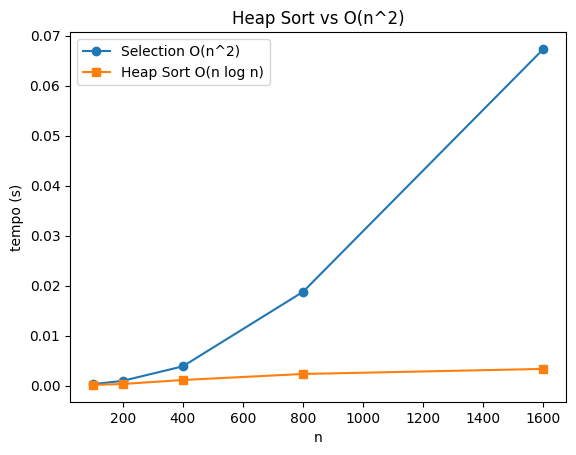

In [19]:
# Visualização: Heap Sort vs ordenação ingenua O(n^2)
import matplotlib.pyplot as plt
import random

def selection_sort(a):
    a = a[:]
    for i in range(len(a)):
        m = min(range(i, len(a)), key=lambda j: a[j])
        a[i], a[m] = a[m], a[i]
    return a

def conta_ops(sort_fn, n):
    # proxy simples de custo: tamanho da entrada vs tempo relativo de passos
    import time
    dados = [random.randint(0, 10000) for _ in range(n)]
    t0 = time.perf_counter()
    sort_fn(dados)
    return time.perf_counter() - t0

tamanhos = [100, 200, 400, 800, 1600]
t_heap = [conta_ops(heap_sort, n) for n in tamanhos]
t_sel = [conta_ops(selection_sort, n) for n in tamanhos]

plt.plot(tamanhos, t_sel, 'o-', label='Selection O(n^2)')
plt.plot(tamanhos, t_heap, 's-', label='Heap Sort O(n log n)')
plt.xlabel('n'); plt.ylabel('tempo (s)'); plt.legend(); plt.title('Heap Sort vs O(n^2)')
plt.show()

## Desafio Final

Implemente um **fluxo de mediana** (running median): dado um fluxo de números,
mantenha a mediana corrente após cada inserção usando **dois heaps** — um
max-heap com a metade menor e um min-heap com a metade maior. Cada inserção
deve custar $O(\log n)$.


In [20]:
# Desafio: mediana de um fluxo com dois heaps
# TODO: complete a classe abaixo (use heapq; lembre que para um max-heap basta
# armazenar valores negados).
import heapq

class MedianaFluxo:
    def __init__(self):
        self.menores = []  # max-heap (valores negados)
        self.maiores = []  # min-heap

    def adicionar(self, x):
        # TODO: insira x no heap correto e rebalanceie os tamanhos
        heapq.heappush(self.menores, -x)
        heapq.heappush(self.maiores, -heapq.heappop(self.menores))
        if len(self.menores) < len(self.maiores):
            heapq.heappush(self.menores, -heapq.heappop(self.maiores))



    def mediana(self):
        # TODO: retorne a mediana corrente
      if len(self.menores) > len(self.maiores):
        return -self.menores[0]  # desnega o topo do max-heap
      else:
        return (-self.menores[0] + self.maiores[0]) / 2

# Teste sugerido (descomente após implementar):
m = MedianaFluxo()
for v in [5, 15, 1, 3]:
     m.adicionar(v)
print(m.mediana())  # 4.0

4.0


## Referências

Veja o arquivo `../referencias.bib` para a lista completa (CLRS, Sedgewick &
Wayne, Williams 1964, Floyd 1964, Ziviani).
